In [126]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display_latex
x_chor = np.load('x_chor_output.npy')
v_chor = np.load('v_chor_output.npy')

In [127]:
# Choreography Testing
M = np.ones(3)
G = 1
x0 = x_chor
v0 = v_chor
#Centre of Mass
CoM0 = np.zeros(3)
v_CoM0 = np.zeros(3)
total_mass = np.sum(M, axis= 0)

for i in range(3):
    CoM0 += M[i] * x0[i, :]/total_mass
    v_CoM0 += M[i] * v0[i, :]/total_mass
print(CoM0)
print(v_CoM0)

[0.00000000e+00 2.77555756e-17 0.00000000e+00]
[2.77555756e-17 0.00000000e+00 0.00000000e+00]


In [122]:
#-----------------------------------------Initial conditions for Figure 8------------------------------------------
M = np.array([1, 1, 1])

x0 = np.array([
    [ 0.0,         0.0,        0.0],
    [-0.97000436,  0.24308753, 0.0],
    [ 0.97000436, -0.24308753, 0.0]
])

v0 = np.array([
    [-0.93240737,   -0.86473146,   0.0],
    [ 0.4662036850,  0.4323657300, 0.0],
    [ 0.4662036850,  0.4323657300, 0.0]
])

In [70]:
#-----------------------------------------Initial Conditions for Two Body Problem----------------------------------
M = np.array([1, 1])
N = np.size(M)
G = 1


#Initial conditions for Figure 8 
x0 = np.array([[ 0.5, 0, 0],
               [-0.5, 0, 0]])


R = np.linalg.norm(x0[1]-x0[0])
totalM = M[0] + M[1]
v_esc = np.sqrt(2 * G * totalM / R) #Escape Velocity
v_rel = np.sqrt(G * totalM / R) #Circular Velocity

v0= np.array([[0, 1.3*M[1]/totalM * v_rel, 0],
            [0, -1.3*M[0]/totalM * v_rel, 0]])


In [128]:
def acceleration(x, M, G):
    N = np.shape(x)[0]
    a = np.zeros((N, 3))
    U = 0
    for i in range(N):
        for j in range(i+1, N):
            x_i, x_j = x[i, :], x[j, :]
            r_ij = x_j - x_i
            r_ij_norm = np.linalg.norm(r_ij)
            
            #Calculate force exerted on i by each j
            a_ij = G*M[i]*M[j]/(r_ij_norm**3 + 1e-14) * (r_ij)
            a[i, :] += a_ij/M[i]
            a[j, :] -= a_ij/M[j]
            
            #Calculating potentials
            U_ij = -G*M[i]*M[j]/(r_ij_norm)
            U += U_ij 
    return a, U

In [ ]:
def nBodyYoshida(M, x0, v0, dt, timesteps):
    
    #Constants
    G = 1
    N = np.size(M)
    colors = plt.cm.viridis(np.linspace(0, 1, N))
    time = np.arange(timesteps)

    #Centre of Mass
    CoM0 = np.zeros(3)
    v_CoM0 = np.zeros(3)
    total_mass = np.sum(M, axis= 0)
    
    for i in range(N):
        CoM0 += M[i] * x0[i, :]/total_mass
        v_CoM0 += M[i] * v0[i, :]/total_mass

    #Position/Velocity Vectors
    x = np.zeros((N, 3, timesteps))
    v = np.zeros((N, 3, timesteps))
    
    x[:, :, 0] = x0-CoM0
    v[:, :, 0] = v0-v_CoM0

    _, U0 = acceleration(x[:, :, 0], M, G)

    #Yoshida Coefficients
    w0 = -((2)**(1/3))/(2-2**(1/3))
    w1 = 1/(2-2**(1/3))
    c1 = w1/2
    c2 = (w0+w1)/2
    c3 = (w0+w1)/2
    c4 = w1/2
    d1 = w1
    d2 = w0
    d3 = w1

    #Conserved Quantities
    T = np.zeros(timesteps) # KE
    U = np.zeros(timesteps) # PE
    P = np.zeros((3, timesteps)) # Momentum
    L = np.zeros((3, timesteps)) #Angular Momentum

    T[0] = np.sum(0.5*M*np.linalg.norm(v[:, :, 0], axis = 1)**2)
    U[0] = U0 
    
    for i in range(N):
        x_i = x[i, :, 0]
        u_i = v[i, :, 0]
        P_i = M[i] * u_i
        L_i = np.cross(x_i, P_i)
        
        P[:, 0] += P_i
        L[:, 0] += L_i 
        
    for k in range(timesteps-1):
        
        #First Step
        x_int1 = x[:, :, k] + c1*v[:, :, k]*dt
        a_int1, _ = acceleration(x_int1, M, G)
        v_int1 = v[:, :, k] + d1*a_int1*dt

        #Second Step
        x_int2 = x_int1 + c2*v_int1*dt
        a_int2, _ = acceleration(x_int2, M, G)
        v_int2 = v_int1 + d2*a_int2*dt

        #Third Step
        x_int3 = x_int2 + c3*v_int2*dt
        a_int3, _ = acceleration(x_int3, M, G)
        v_int3 = v_int2 + d3*a_int3*dt

        #Final Step
        x[:, :, k+1] = x_int3 + c4*v_int3*dt
        _, U_int4 = acceleration(x[:, :, k+1], M, G)
        v[:, :, k+1] = v_int3


        T[k+1] = np.sum(0.5*M*(np.linalg.norm(v[:, :, k+1], axis = 1)**2))
        U[k+1] = U_int4

        for i in range(N):
            x_i = x[i, :, k+1]
            v_i = v[i, :, k+1]
            P_i = M[i] * v_i
            L_i = np.cross(x_i, P_i)
        
            P[:, k+1] += P_i
            L[:, k+1] += L_i 
    #Conserved Quantities Errors
    E = T + U
    P0, P_error_denominator = P[:, 0], P[:, 0]
    L0, L_error_denominator = L[:, 0], L[:, 0]
    E_error = np.abs((E-E[0])/E[0])
    
    if np.linalg.norm(P[:, 0]) == 0:
        for i in range(N):
            v0_i = v0[i, :]
            if np.linalg.norm(v0_i) != 0:
                P_error_denominator = M[i]*v0_i
                break
    
    if np.linalg.norm(L[:, 0]) == 0:
        for i in range(N):
            x0_i = x0[i, :]
            v0_i = v0[i, :]
            P0_i = M[i]*v0_i
            L0_i = np.cross(x0_i, P0_i)
            if np.linalg.norm(L0_i) != 0:
                L_error_denominator = L0_i
                break
    
    P_error = np.linalg.norm((P-P0[:, None]), axis = 0)/np.linalg.norm(P_error_denominator)
    L_error = np.linalg.norm((L-L0[:, None]), axis = 0)/np.linalg.norm(L_error_denominator)
    
    # Plotting the orbits
    fig1, axa = plt.subplots()
    #axa.scatter(0, 0, color = 'black', label = "Centre of Mass")
    for i in range(N):
        axa.plot(x[i, 0, :], x[i, 1, :], color = colors[i], label = f"Body {i}")
        axa.scatter(x[i, 0, 0], x[i, 1, 0], color = colors[i], label = f"Mass {i} Start ")
        axa.scatter(x[i, 0, -1], x[i, 1, -1], facecolor = 'None', edgecolor = colors[i], label = f"Mass {i} End ")
        plt.gca().set_aspect('equal', adjustable='box')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5)) 

    fig2, axb = plt.subplots(3, 1, figsize = (8, 8))
    axb[0].plot(time, 100*E_error)
    axb[0].set_title("Energy Error")
    axb[0].set_ylabel("Error (%)")
    axb[0].set_xlabel("Timestep") 
    axb[1].plot(time, 100*P_error)
    axb[1].set_title("Momentum Error (%)")
    axb[1].set_ylabel("Error (%)")
    axb[1].set_xlabel("Timestep") 
    axb[2].plot(time, 100*L_error)
    axb[2].set_title("Ang. Momentum Error (%)")
    axb[2].set_ylabel("Error (%)")
    axb[2].set_xlabel("Timestep") 
    plt.tight_layout()
    return x, v, U, T

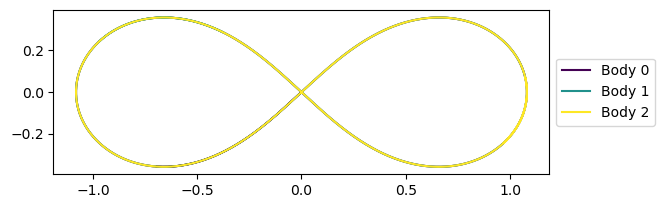

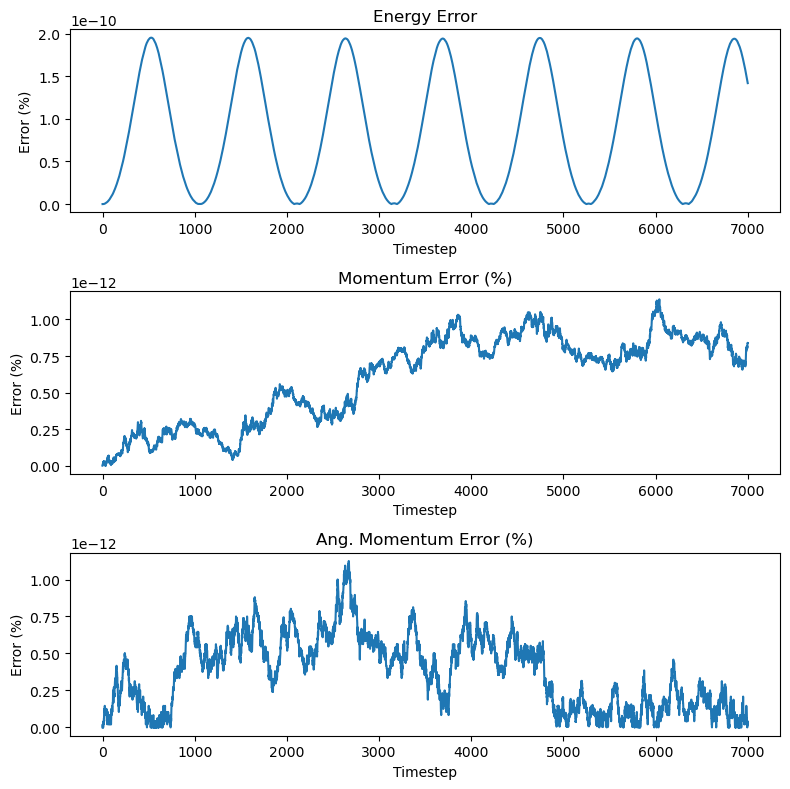

In [124]:
#Scale
x, v, U, T = nBodyYoshida(M, x0, v0, 0.001, 7000)
# plt.scatter(x[0, 0, 0], x[0, 1, 0])
# plt.scatter(x[1, 0, 0], x[1, 1, 0])
# plt.scatter(x[2, 0, 0], x[2, 1, 0])

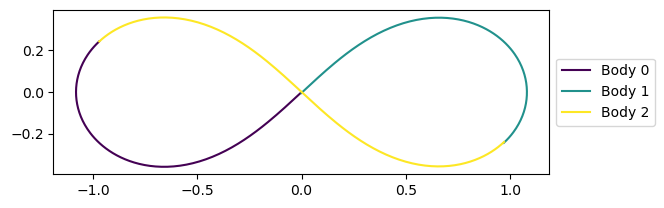

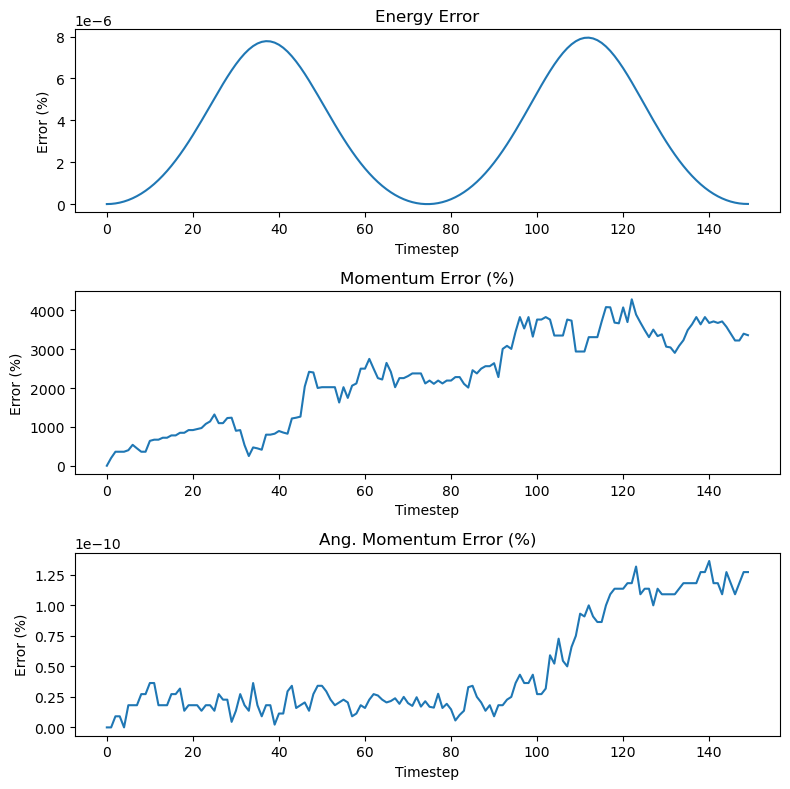

In [132]:
K = 150
time = np.linspace(0, 6.3259/3, K)
dt = time[1] - time[0]

#Scale
lam = (1/6.3259)**(2/3)
mu = 1/6.3259

x, v, U, T = nBodyYoshida(M, x0, v0, dt, K)

# np.save('FIG8_x.npy', x[:, :, 0:K-1])
# np.save('FIG8_v.npy', v[:, :, 0:K-1])
# np.save('FIG8_U.npy', U[0:K-1])
# np.save('FIG8_T.npy', T[0:K-1])

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

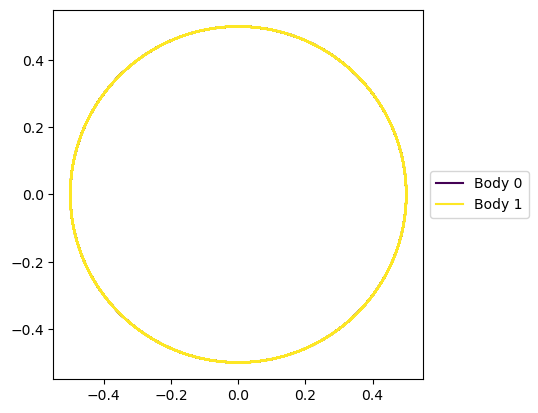

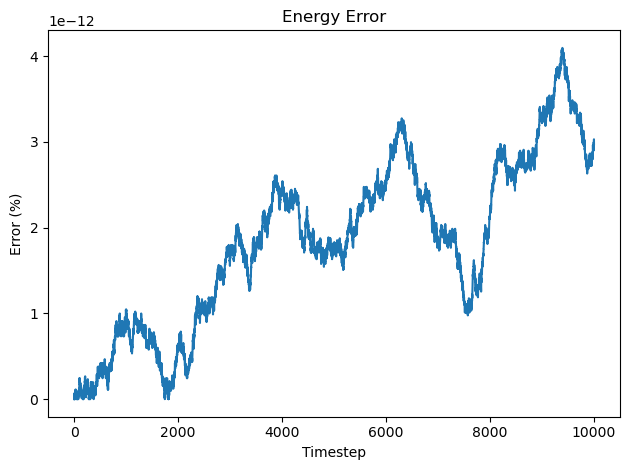

In [67]:
dt = np.array([0.01*(0.5**k) for k in range(8)])
s = np.zeros(8)
v0 = np.array([[0, 1.0*M[1]/totalM * v_rel, 0],
                [0, -1.0*M[0]/totalM * v_rel, 0]])

for i in range(8):
    s[i] = max(nBodyYoshida(M, x0, v0, dt[i], 10000))

plt.plot(np.log(dt), np.log(s))
gradient = np.diff(np.log(s)) / np.diff(np.log(dt))
print(gradient)
average_slope = np.mean(gradient)
print("Average slope:", average_slope)
